In [9]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms
from PIL import Image
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import timm
from tqdm import tqdm # For progress bars
import seaborn as sns

In [10]:
BASE_DATA_DIR = './kaggle'
IMAGE_SIZE = 224
BATCH_SIZE = 32
NUM_CLASSES = 3 # Type A, Type B, Type C
LEARNING_RATE = 0.0001
NUM_EPOCHS = 10 # You'll likely need more epochs for optimal results
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
CLASS_NAMES = ['Type A', 'Type B', 'Type C']

print(f"Using device: {DEVICE}")

Using device: cuda


In [11]:
class CervicalCancerDataset(Dataset):
    def __init__(self, base_dir, transform=None):
        self.base_dir = base_dir
        self.transform = transform
        self.image_paths = []
        self.labels = [] # 0 for Type A, 1 for Type B, 2 for Type C

        # Assuming 'additonal_type_1_v2' is Type A, 'additonal_type_2_v2' is Type B, etc.
        # This part assumes your training data is structured directly within these folders
        # If your 'train' folder contains subfolders like 'TypeA', 'TypeB', 'TypeC', adjust this accordingly.
        # Based on your description, the 'additonal_type_X_v2' look like the actual training data.

        class_mapping = {
            'additional_Type_1_v2/Type_1': 0, # Type A
            'additional_Type_2_v2/Type_2': 1, # Type B
            'additional_Type_3_v2/Type_3': 2  # Type C
        }

        print("Scanning dataset directories...")
        for class_name, label in class_mapping.items():
            class_dir = os.path.join(base_dir, class_name)
            if not os.path.isdir(class_dir):
                print(f"Warning: Directory {class_dir} not found. Skipping.")
                continue

            for img_name in os.listdir(class_dir):
                if img_name.lower().endswith(('.png', '.jpg', '.jpeg')):
                    self.image_paths.append(os.path.join(class_dir, img_name))
                    self.labels.append(label)
        print(f"Found {len(self.image_paths)} images across {NUM_CLASSES} classes.")

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        image = Image.open(img_path).convert('RGB') # Ensure 3 channels
        label = self.labels[idx]

        if self.transform:
            image = self.transform(image)

        return image, label

# --- Data Transformations ---
# Augmentations for training data
train_transforms = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1, hue=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]), # ImageNet means and stds
])

# Transformations for validation/test data (no augmentation)
val_transforms = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

# Create dataset instances
full_dataset = CervicalCancerDataset(base_dir=BASE_DATA_DIR, transform=train_transforms)

# Split into training and validation sets
# It's good practice to hold out some data for validation during training
train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size
train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])

# Apply validation transforms to the validation dataset
# Note: transforms applied during random_split refer to the original dataset's transform.
# A common pattern is to redefine the validation dataset with its own transform if desired,
# or ensure the initial 'full_dataset' transformation is suitable for both
# if you plan to override in __getitem__ or have separate dataset objects.
# For simplicity, here we'll assume `val_dataset` is created from `full_dataset` which uses `train_transforms`.
# If you want to use `val_transforms` for the `val_dataset` split, you'd need to adjust how `full_dataset` is created
# or create two separate dataset objects and then load them into the split.
# For now, let's just make sure the `val_dataset` uses the correct transform:
val_dataset.dataset.transform = val_transforms # This modifies the original dataset's transform for the subset.
                                            # A cleaner way for large projects might be to create separate
                                            # CervicalCancerDataset instances for train and val with their specific transforms.

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f"Training on {len(train_dataset)} images, validating on {len(val_dataset)} images.")

Scanning dataset directories...
Found 6184 images across 3 classes.
Training on 4947 images, validating on 1237 images.


In [5]:
def train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs, model_name):
    print(f"\n--- Starting training for {model_name} ---")
    model.to(DEVICE)

    train_losses = []
    val_losses = []
    val_accuracies = []

    best_val_accuracy = 0.0

    # Store all predictions and true labels from the best epoch for confusion matrix
    best_epoch_all_preds = []
    best_epoch_all_labels = []

    for epoch in range(num_epochs):
        model.train() # Set model to training mode
        running_loss = 0.0
        # ... (your existing training loop code) ...
        correct_predictions = 0
        total_samples = 0

        train_loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Train]", leave=False)
        for inputs, labels in train_loop:
            inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)

            optimizer.zero_grad()

            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs.data, 1)
            total_samples += labels.size(0)
            correct_predictions += (predicted == labels).sum().item()

            train_loop.set_postfix(loss=loss.item())

        epoch_train_loss = running_loss / len(train_loader.dataset)
        train_losses.append(epoch_train_loss)
        train_accuracy = correct_predictions / total_samples
        print(f"Epoch {epoch+1}/{num_epochs} - Train Loss: {epoch_train_loss:.4f}, Train Acc: {train_accuracy:.4f}")

        # --- Validation Phase ---
        model.eval() # Set model to evaluation mode
        val_loss = 0.0
        all_preds = []
        all_labels = []

        with torch.no_grad():
            val_loop = tqdm(val_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Validation]", leave=False)
            for inputs, labels in val_loop:
                inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
                outputs = model(inputs)
                loss = criterion(outputs, labels)

                val_loss += loss.item() * inputs.size(0)
                _, predicted = torch.max(outputs.data, 1)

                all_preds.extend(predicted.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())

                val_loop.set_postfix(loss=loss.item())

        epoch_val_loss = val_loss / len(val_loader.dataset)
        val_losses.append(epoch_val_loss)

        val_accuracy = accuracy_score(all_labels, all_preds)
        val_precision = precision_score(all_labels, all_preds, average='weighted', zero_division=0)
        val_recall = recall_score(all_labels, all_preds, average='weighted', zero_division=0)
        val_f1 = f1_score(all_labels, all_preds, average='weighted', zero_division=0)
        val_accuracies.append(val_accuracy)

        print(f"Epoch {epoch+1}/{num_epochs} - Val Loss: {epoch_val_loss:.4f}, Val Acc: {val_accuracy:.4f}, "
              f"Val Precision: {val_precision:.4f}, Val Recall: {val_recall:.4f}, Val F1: {val_f1:.4f}")

        # Save best model (optional) and store predictions for confusion matrix
        if val_accuracy > best_val_accuracy:
            best_val_accuracy = val_accuracy
            torch.save(model.state_dict(), f'{model_name}_best_model.pth')
            print(f"Saved best model for {model_name} with accuracy: {best_val_accuracy:.4f}")
            best_epoch_all_preds = all_preds # Store predictions from the best epoch
            best_epoch_all_labels = all_labels # Store true labels from the best epoch

    print(f"--- Training finished for {model_name} ---")
    # Return collected losses, accuracies, and the best epoch's predictions/labels
    return train_losses, val_losses, val_accuracies, best_epoch_all_preds, best_epoch_all_labels


def plot_results(train_losses, val_losses, val_accuracies, model_name):
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(train_losses, label='Train Loss')
    plt.plot(val_losses, label='Validation Loss')
    plt.title(f'{model_name} Loss over Epochs')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(val_accuracies, label='Validation Accuracy', color='green')
    plt.title(f'{model_name} Validation Accuracy over Epochs')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.tight_layout()
    plt.show()
    


In [13]:
def plot_confusion_matrix(all_labels, all_preds, class_names, model_name):
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
    plt.title(f'Confusion Matrix for {model_name}')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.show()


--- Training ResNet50 ---

--- Starting training for ResNet50 ---


Epoch 1/10 - Train Loss: 0.9234, Train Acc: 0.5737


Epoch 1/10 - Val Loss: 0.8693, Val Acc: 0.5772, Val Precision: 0.4823, Val Recall: 0.5772, Val F1: 0.4328
Saved best model for ResNet50 with accuracy: 0.5772


Epoch 2/10 - Train Loss: 0.8364, Train Acc: 0.5878


Epoch 2/10 - Val Loss: 0.8250, Val Acc: 0.5909, Val Precision: 0.5293, Val Recall: 0.5909, Val F1: 0.4863
Saved best model for ResNet50 with accuracy: 0.5909


...

Epoch 8/10 - Val Loss: 0.8354, Val Acc: 0.7082, Val Precision: 0.7050, Val Recall: 0.7082, Val F1: 0.7011
Saved best model for ResNet50 with accuracy: 0.7082


Epoch 9/10 - Train Loss: 0.1084, Train Acc: 0.9707


Epoch 9/10 - Val Loss: 0.8545, Val Acc: 0.7227, Val Precision: 0.7230, Val Recall: 0.7227, Val F1: 0.7217
Saved best model for ResNet50 with accuracy: 0.7227


Epoch 10/10 - Train Loss: 0.0639, Train Acc: 0.9844


Epoch 10/10 - Val Loss: 1.0473, Val Acc: 0.7098, Val Precision: 0.7105, Val Recall: 0.7098, Val F1: 0.7000
--- Training finished for ResNet50 ---


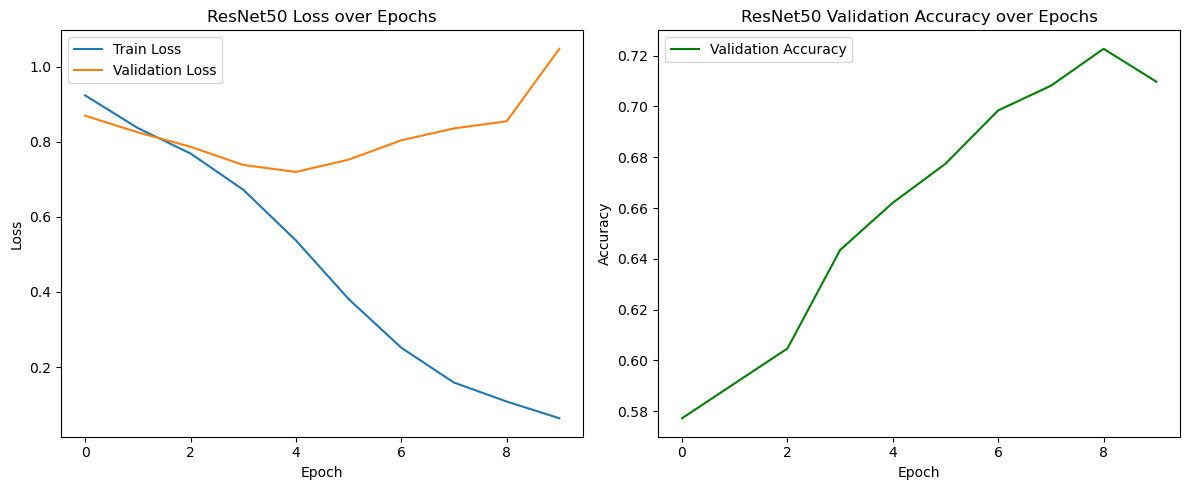

In [6]:
# ResNet50
print("\n--- Training ResNet50 ---")
model_resnet50 = timm.create_model('resnet50', pretrained=True, num_classes=NUM_CLASSES)
# Modify the final classification layer for your specific number of classes
model_resnet50.fc = nn.Linear(model_resnet50.fc.in_features, NUM_CLASSES)

criterion_resnet50 = nn.CrossEntropyLoss()
optimizer_resnet50 = optim.Adam(model_resnet50.parameters(), lr=LEARNING_RATE)

train_losses_resnet50, val_losses_resnet50, val_accuracies_resnet50, \
    resnet50_preds, resnet50_labels = \
    train_model(model_resnet50, train_loader, val_loader, criterion_resnet50, optimizer_resnet50, NUM_EPOCHS, "ResNet50")

plot_results(train_losses_resnet50, val_losses_resnet50, val_accuracies_resnet50, "ResNet50")
plot_confusion_matrix(resnet50_labels, resnet50_preds, CLASS_NAMES, "ResNet50")


--- Training MobileNetV3 ---

--- Starting training for MobileNetV3 ---


Epoch 1/10 - Train Loss: 0.8390, Train Acc: 0.5992


Epoch 1/10 - Val Loss: 0.7474, Val Acc: 0.6362, Val Precision: 0.6380, Val Recall: 0.6362, Val F1: 0.5940
Saved best model for MobileNetV3 with accuracy: 0.6362


Epoch 2/10 - Train Loss: 0.6402, Train Acc: 0.7158


Epoch 2/10 - Val Loss: 0.6529, Val Acc: 0.7033, Val Precision: 0.7070, Val Recall: 0.7033, Val F1: 0.6880
Saved best model for MobileNetV3 with accuracy: 0.7033


...

Epoch 8/10 - Val Loss: 0.9011, Val Acc: 0.7486, Val Precision: 0.7494, Val Recall: 0.7486, Val F1: 0.7488


Epoch 9/10 - Train Loss: 0.0233, Train Acc: 0.9929


Epoch 9/10 - Val Loss: 0.9971, Val Acc: 0.7631, Val Precision: 0.7614, Val Recall: 0.7631, Val F1: 0.7617
Saved best model for MobileNetV3 with accuracy: 0.7631


Epoch 10/10 - Train Loss: 0.0232, Train Acc: 0.9919


Epoch 10/10 - Val Loss: 1.1142, Val Acc: 0.7583, Val Precision: 0.7562, Val Recall: 0.7583, Val F1: 0.7545
--- Training finished for MobileNetV3 ---


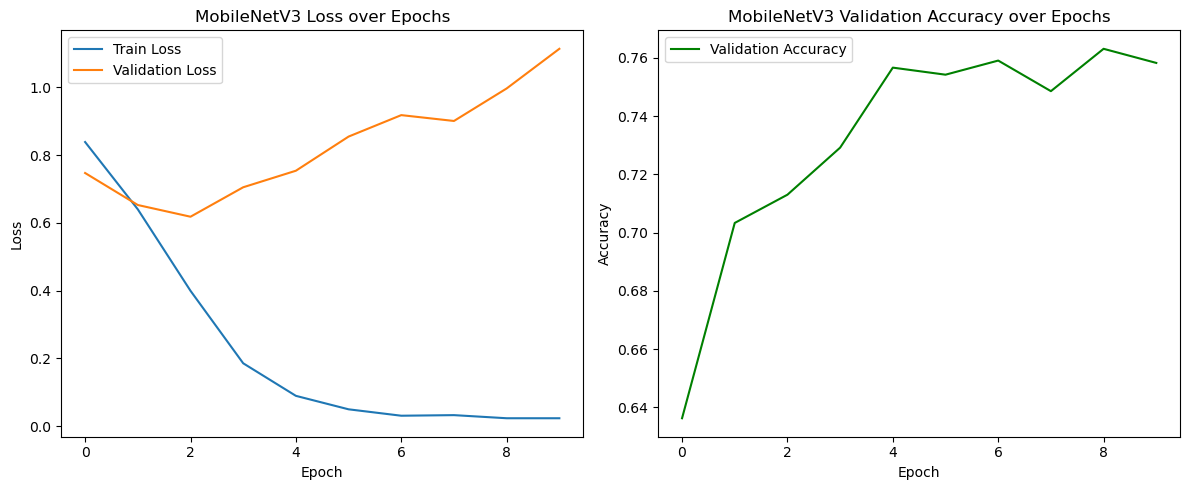

In [7]:
# MobileNetV3
print("\n--- Training MobileNetV3 ---")
# 'mobilenetv3_large_100' is a common choice for MobileNetV3, pretrained=True loads ImageNet weights
model_mobilenet = timm.create_model('mobilenetv3_large_100', pretrained=True, num_classes=NUM_CLASSES)
model_mobilenet.classifier = nn.Linear(model_mobilenet.classifier.in_features, NUM_CLASSES) # Ensure output layer is correct

# Loss function and Optimizer
criterion_mobilenet = nn.CrossEntropyLoss()
optimizer_mobilenet = optim.Adam(model_mobilenet.parameters(), lr=LEARNING_RATE)

train_losses_mobilenet, val_losses_mobilenet, val_accuracies_mobilenet, \
    mobilenet_preds, mobilenet_labels = \
    train_model(model_mobilenet, train_loader, val_loader, criterion_mobilenet, optimizer_mobilenet, NUM_EPOCHS, "MobileNetV3")

plot_results(train_losses_mobilenet, val_losses_mobilenet, val_accuracies_mobilenet, "MobileNetV3")
plot_confusion_matrix(mobilenet_labels, mobilenet_preds, CLASS_NAMES, "MobileNetV3")


--- Training EfficientNet-B3 ---


model.safetensors:   0%|          | 0.00/49.3M [00:00<?, ?B/s]

C:\Users\User\miniconda3\Lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\User\.cache\huggingface\hub\models--timm--efficientnet_b3.ra2_in1k. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)



--- Starting training for EfficientNet-B3 ---


Epoch 1/10 - Train Loss: 0.8477, Train Acc: 0.5929


...

Epoch 8/10 - Val Loss: 0.9241, Val Acc: 0.7518, Val Precision: 0.7505, Val Recall: 0.7518, Val F1: 0.7502


Epoch 9/10 - Train Loss: 0.0186, Train Acc: 0.9933


Epoch 9/10 - Val Loss: 0.9620, Val Acc: 0.7534, Val Precision: 0.7549, Val Recall: 0.7534, Val F1: 0.7510


Epoch 10/10 - Train Loss: 0.0168, Train Acc: 0.9960


Epoch 10/10 - Val Loss: 0.9845, Val Acc: 0.7429, Val Precision: 0.7513, Val Recall: 0.7429, Val F1: 0.7449
--- Training finished for EfficientNet-B3 ---


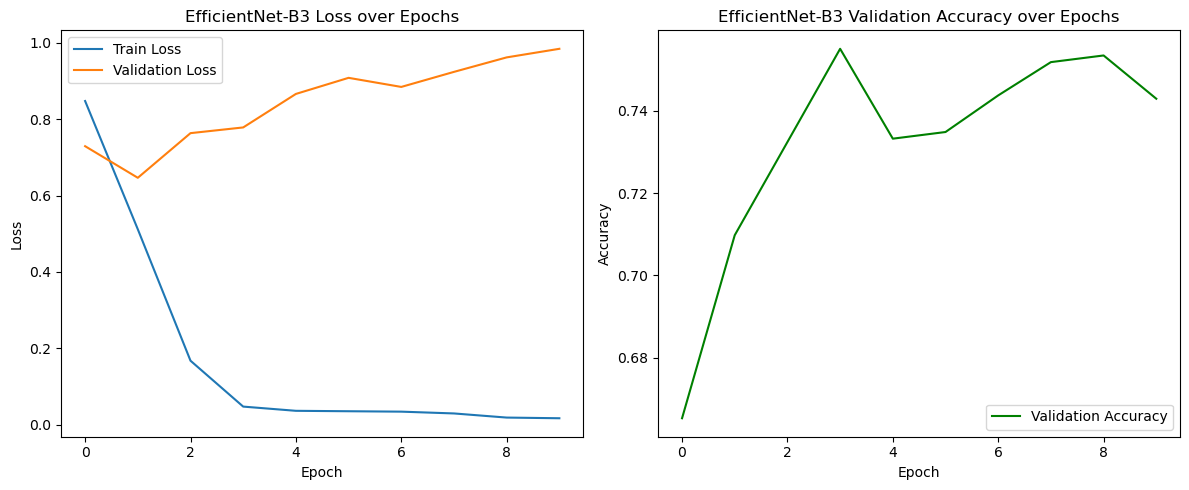

In [8]:
# EfficientNet-B3
print("\n--- Training EfficientNet-B3 ---")
model_efficientnetb3 = timm.create_model('efficientnet_b3', pretrained=True, num_classes=NUM_CLASSES)
# For EfficientNet, the classifier is often named '_fc' or 'classifier' depending on the exact variant
# You might need to inspect the model's structure if this doesn't work: print(model_efficientnetb3)
model_efficientnetb3.classifier = nn.Linear(model_efficientnetb3.classifier.in_features, NUM_CLASSES)


criterion_efficientnetb3 = nn.CrossEntropyLoss()
optimizer_efficientnetb3 = optim.Adam(model_efficientnetb3.parameters(), lr=LEARNING_RATE)

train_losses_efficientnetb3, val_losses_efficientnetb3, val_accuracies_efficientnetb3, \
    efficientnetb3_preds, efficientnetb3_labels = \
    train_model(model_efficientnetb3, train_loader, val_loader, criterion_efficientnetb3, optimizer_efficientnetb3, NUM_EPOCHS, "EfficientNet-B3")

plot_results(train_losses_efficientnetb3, val_losses_efficientnetb3, val_accuracies_efficientnetb3, "EfficientNet-B3")
plot_confusion_matrix(efficientnetb3_labels, efficientnetb3_preds, CLASS_NAMES, "EfficientNet-B3")


Scanning dataset directories...
Found 6184 images across 3 classes.

--- Evaluating MobileNetV3 ---


MobileNetV3 Evaluation Results:
  Loss: 0.1952
  Accuracy: 0.9539
  Precision: 0.9539
  Recall: 0.9539
  F1-Score: 0.9539


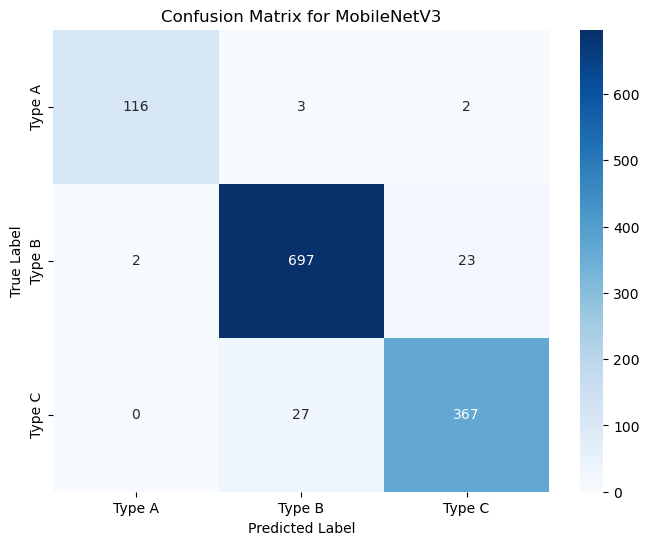


--- Evaluating ResNet50 ---


ResNet50 Evaluation Results:
  Loss: 0.1764
  Accuracy: 0.9475
  Precision: 0.9476
  Recall: 0.9475
  F1-Score: 0.9475


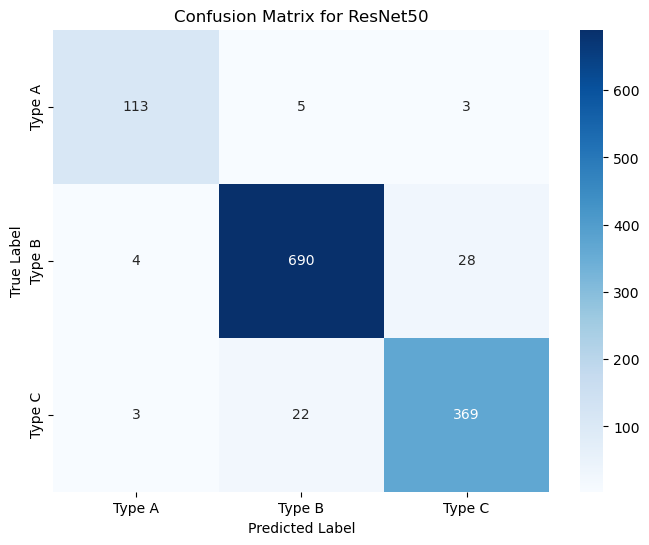


--- Evaluating EfficientNet-B3 ---


EfficientNet-B3 Evaluation Results:
  Loss: 0.1585
  Accuracy: 0.9523
  Precision: 0.9523
  Recall: 0.9523
  F1-Score: 0.9523


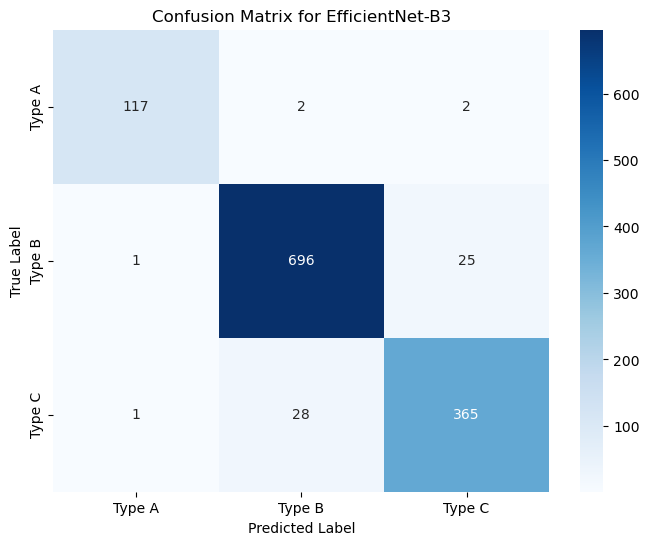

In [15]:
# --- Function to evaluate a loaded model ---
def evaluate_model_and_get_preds(model, data_loader, criterion, model_name):
    print(f"\n--- Evaluating {model_name} ---")
    model.eval() # Set model to evaluation mode
    all_preds = []
    all_labels = []
    total_loss = 0.0

    with torch.no_grad():
        eval_loop = tqdm(data_loader, desc=f"Evaluating {model_name}", leave=False)
        for inputs, labels in eval_loop:
            inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
            outputs = model(inputs)
            loss = criterion(outputs, labels)

            total_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs.data, 1)

            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    avg_loss = total_loss / len(data_loader.dataset)
    accuracy = accuracy_score(all_labels, all_preds)
    precision = precision_score(all_labels, all_preds, average='weighted', zero_division=0)
    recall = recall_score(all_labels, all_preds, average='weighted', zero_division=0)
    f1 = f1_score(all_labels, all_preds, average='weighted', zero_division=0)

    print(f"{model_name} Evaluation Results:")
    print(f"  Loss: {avg_loss:.4f}")
    print(f"  Accuracy: {accuracy:.4f}")
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall: {recall:.4f}")
    print(f"  F1-Score: {f1:.4f}")

    return all_labels, all_preds

# Create a dataset for validation (or a dedicated test set if you have one)
# IMPORTANT: Use the same split as you did for training, or a completely separate test set.
# For simplicity, here we'll re-split the full_dataset but ensure it uses val_transforms.
full_dataset_eval = CervicalCancerDataset(base_dir=BASE_DATA_DIR, transform=val_transforms)
train_size = int(0.8 * len(full_dataset_eval))
val_size = len(full_dataset_eval) - train_size
# Note: To ensure you get the *same* validation split as during training,
# you should ideally save the indices or use a fixed random seed.
# For demonstration, we'll just re-split.
_, eval_dataset = random_split(full_dataset_eval, [train_size, val_size], generator=torch.Generator().manual_seed(42)) # Using a fixed seed

eval_loader = DataLoader(eval_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0) # num_workers=0 crucial for Windows/Jupyter

# Define a common criterion for evaluation
criterion = nn.CrossEntropyLoss()
# --- Load and evaluate MobileNetV3 ---
model_name_mobilenet = "MobileNetV3"
model_mobilenet = timm.create_model('mobilenetv3_large_100', pretrained=False, num_classes=NUM_CLASSES)
model_mobilenet.classifier = nn.Linear(model_mobilenet.classifier.in_features, NUM_CLASSES)
model_mobilenet.load_state_dict(torch.load(f'{model_name_mobilenet}_best_model.pth', map_location=DEVICE))
model_mobilenet.to(DEVICE)
mobilenet_labels, mobilenet_preds = evaluate_model_and_get_preds(model_mobilenet, eval_loader, criterion_mobilenet, model_name_mobilenet)
plot_confusion_matrix(mobilenet_labels, mobilenet_preds, CLASS_NAMES, model_name_mobilenet)
# --- Load and evaluate ResNet50 ---
model_name_resnet50 = "ResNet50"
model_resnet50 = timm.create_model('resnet50', pretrained=False, num_classes=NUM_CLASSES)
model_resnet50.fc = nn.Linear(model_resnet50.fc.in_features, NUM_CLASSES)
model_resnet50.load_state_dict(torch.load(f'{model_name_resnet50}_best_model.pth', map_location=DEVICE))
model_resnet50.to(DEVICE)
resnet50_labels, resnet50_preds = evaluate_model_and_get_preds(model_resnet50, eval_loader, criterion, model_name_resnet50)
plot_confusion_matrix(resnet50_labels, resnet50_preds, CLASS_NAMES, model_name_resnet50)


# --- Load and evaluate EfficientNet-B3 ---
model_name_efficientnetb3 = "EfficientNet-B3"
model_efficientnetb3 = timm.create_model('efficientnet_b3', pretrained=False, num_classes=NUM_CLASSES)
model_efficientnetb3.classifier = nn.Linear(model_efficientnetb3.classifier.in_features, NUM_CLASSES)
model_efficientnetb3.load_state_dict(torch.load(f'{model_name_efficientnetb3}_best_model.pth', map_location=DEVICE))
model_efficientnetb3.to(DEVICE)
efficientnetb3_labels, efficientnetb3_preds = evaluate_model_and_get_preds(model_efficientnetb3, eval_loader, criterion, model_name_efficientnetb3)
plot_confusion_matrix(efficientnetb3_labels, efficientnetb3_preds, CLASS_NAMES, model_name_efficientnetb3)